In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [8]:
df = pd.read_csv("../data/Sample - Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
print("Shape:", df.shape)

Shape: (9994, 21)


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [11]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [12]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [13]:
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

daily_sales.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [14]:
daily_sales.shape
daily_sales.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


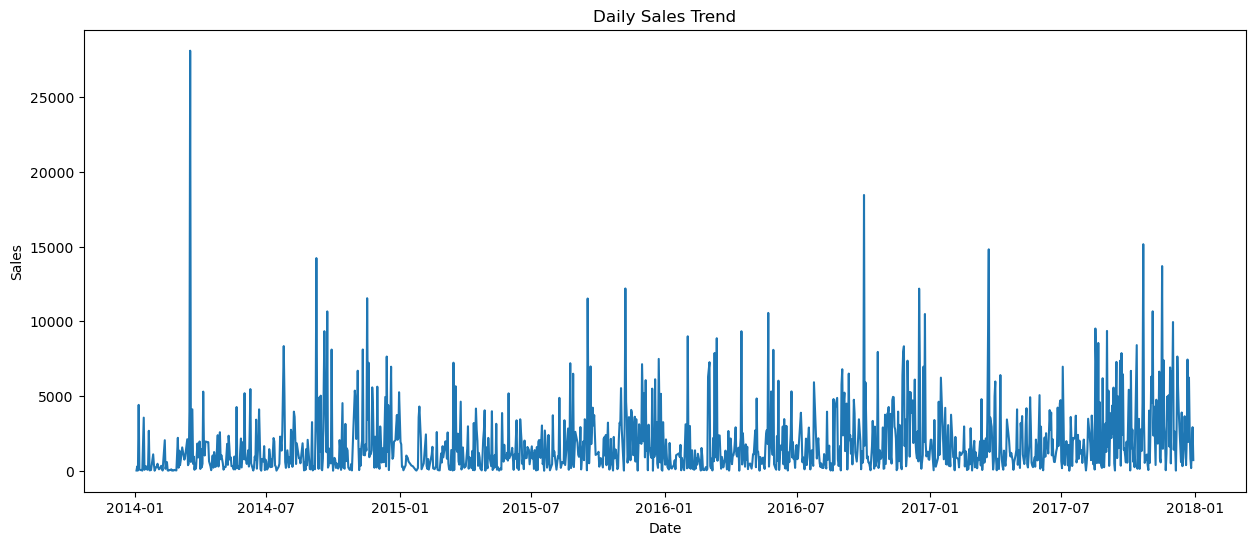

In [15]:
plt.figure(figsize=(15,6))

plt.plot(
    daily_sales['Order Date'],
    daily_sales['Sales']
)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [16]:
daily_sales['Year'] = daily_sales['Order Date'].dt.year
daily_sales['Month'] = daily_sales['Order Date'].dt.month
daily_sales['Day'] = daily_sales['Order Date'].dt.day
daily_sales['Weekday'] = daily_sales['Order Date'].dt.weekday
daily_sales['Quarter'] = daily_sales['Order Date'].dt.quarter

daily_sales.head()

,Order Date,Sales,Year,Month,Day,Weekday,Quarter
0,2014-01-03,16.448,2014,1,3,4,1
1,2014-01-04,288.060,2014,1,4,5,1
2,2014-01-05,19.536,2014,1,5,6,1
3,2014-01-06,4407.100,2014,1,6,0,1
4,2014-01-07,87.158,2014,1,7,1,1


In [17]:
X = daily_sales[['Year', 'Month', 'Day', 'Weekday', 'Quarter']]
y = daily_sales['Sales']

In [18]:
split_index = int(len(daily_sales) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print(X_train.shape)
print(X_test.shape)

(989, 5)
(248, 5)


In [19]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
predictions = model.predict(X_test)

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 1800.0526162419355
RMSE: 2530.6103001863335
R²  : -0.0523650502216475


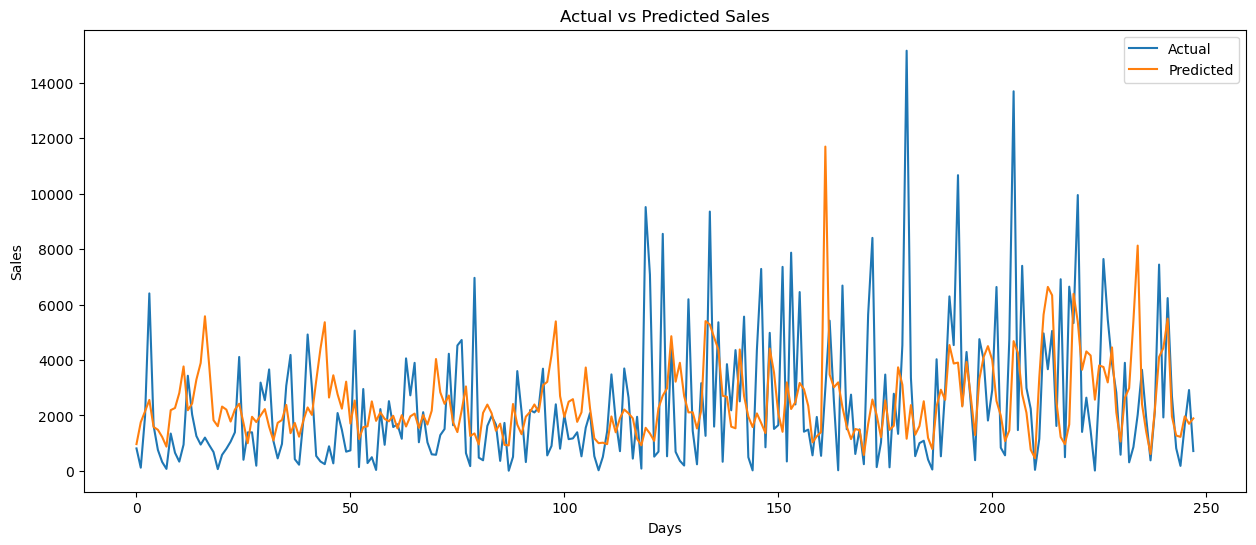

In [22]:
plt.figure(figsize=(15,6))

plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')

plt.title('Actual vs Predicted Sales')
plt.xlabel('Days')
plt.ylabel('Sales')
plt.legend()

plt.show()

In [23]:
daily_sales['Lag_1'] = daily_sales['Sales'].shift(1)
daily_sales['Lag_7'] = daily_sales['Sales'].shift(7)

daily_sales.dropna(inplace=True)

In [24]:
X = daily_sales[
    [
        'Year',
        'Month',
        'Day',
        'Weekday',
        'Quarter',
        'Lag_1',
        'Lag_7'
    ]
]

y = daily_sales['Sales']

In [25]:
split_index = int(len(daily_sales) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [26]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
predictions = model.predict(X_test)

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 1698.259875406504
RMSE: 2383.7337191365036
R²  : 0.06879701198806787


In [30]:
from datetime import timedelta

last_date = daily_sales['Order Date'].max()

future_dates = pd.date_range(
    start=last_date + timedelta(days=1),
    periods=30
)

future_df = pd.DataFrame({
    'Order Date': future_dates
})

future_df['Year'] = future_df['Order Date'].dt.year
future_df['Month'] = future_df['Order Date'].dt.month
future_df['Day'] = future_df['Order Date'].dt.day
future_df['Weekday'] = future_df['Order Date'].dt.weekday
future_df['Quarter'] = future_df['Order Date'].dt.quarter

In [31]:
future_df['Lag_1'] = daily_sales['Sales'].iloc[-1]
future_df['Lag_7'] = daily_sales['Sales'].iloc[-7]


In [32]:
future_predictions = model.predict(
    future_df[
        [
            'Year',
            'Month',
            'Day',
            'Weekday',
            'Quarter',
            'Lag_1',
            'Lag_7'
        ]
    ]
)

future_df['Forecasted_Sales'] = future_predictions

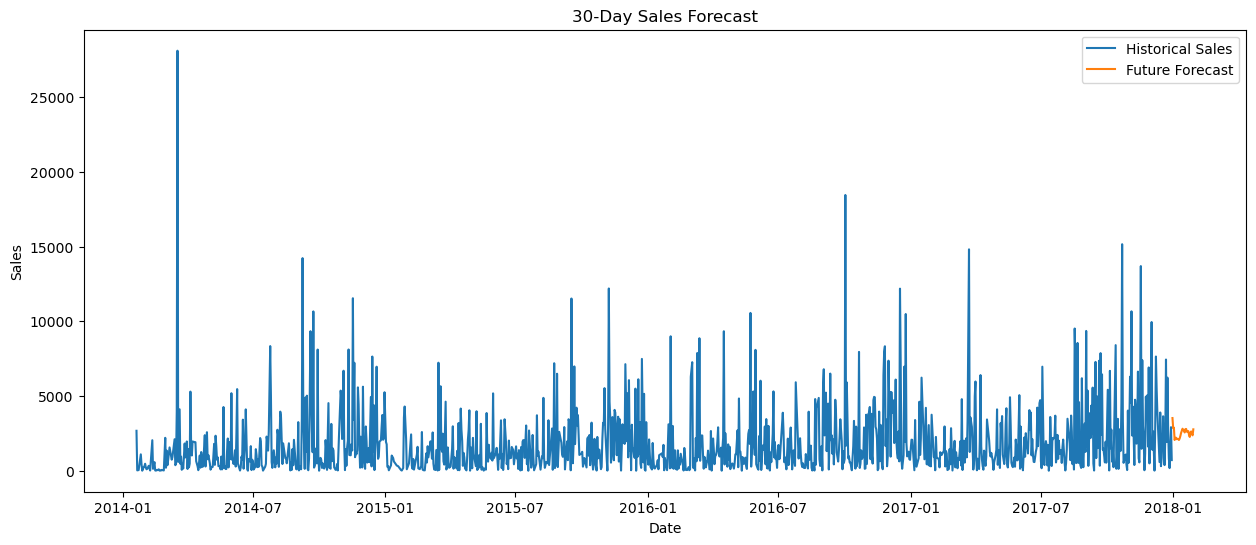

In [33]:
plt.figure(figsize=(15,6))

plt.plot(
    daily_sales['Order Date'],
    daily_sales['Sales'],
    label='Historical Sales'
)

plt.plot(
    future_df['Order Date'],
    future_df['Forecasted_Sales'],
    label='Future Forecast'
)

plt.title('30-Day Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()

plt.show()

In [34]:
import os

os.makedirs("../outputs", exist_ok=True)

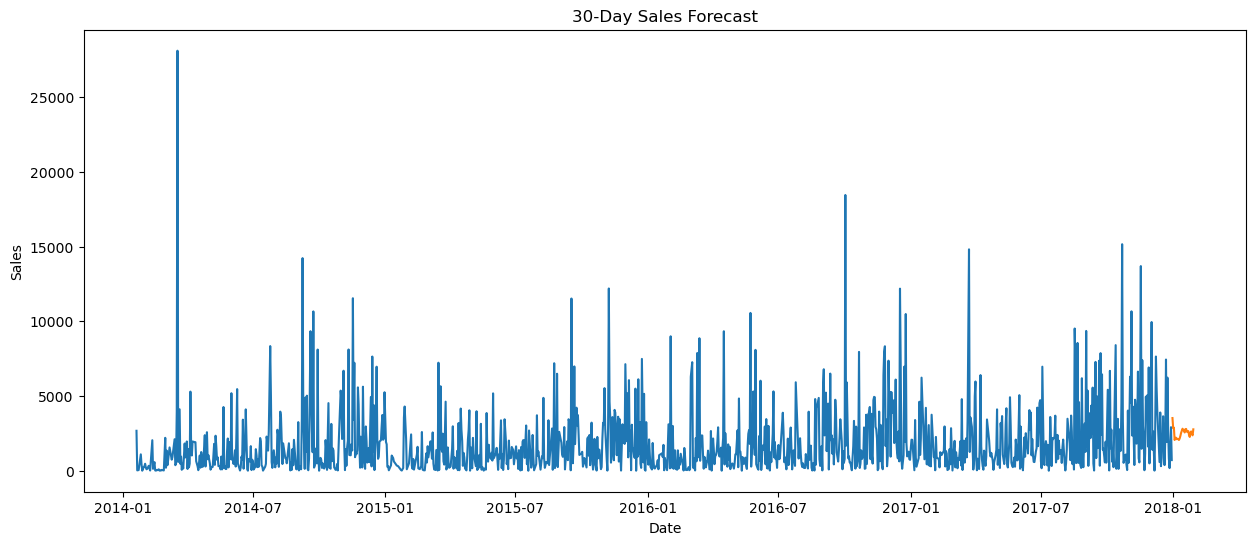

In [35]:
plt.figure(figsize=(15,6))

plt.plot(daily_sales['Order Date'], daily_sales['Sales'])
plt.plot(future_df['Order Date'], future_df['Forecasted_Sales'])

plt.title('30-Day Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.savefig("../outputs/future_forecast.png")
plt.show()

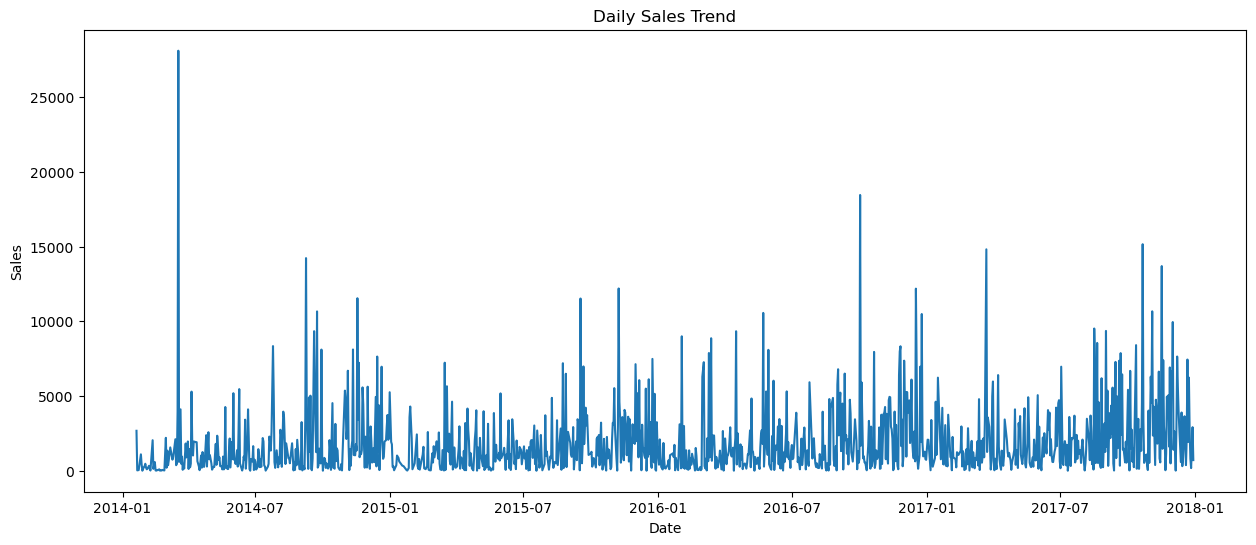

In [36]:
plt.figure(figsize=(15,6))
plt.plot(daily_sales['Order Date'], daily_sales['Sales'])
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.savefig('../outputs/sales_trend.png')
plt.show()

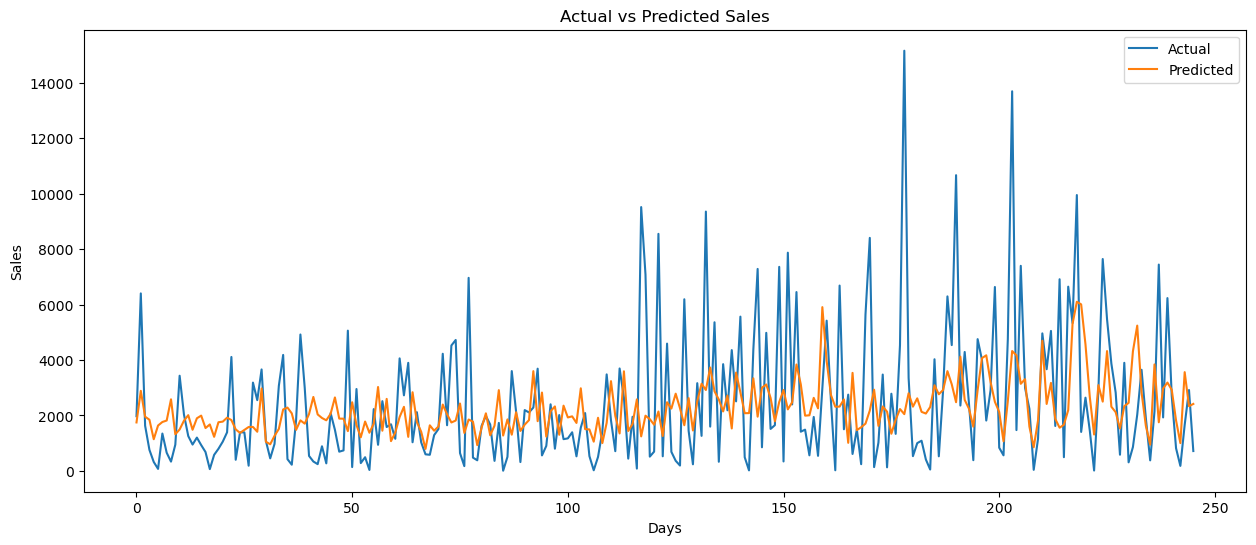

In [37]:
plt.figure(figsize=(15,6))

plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')

plt.title('Actual vs Predicted Sales')
plt.xlabel('Days')
plt.ylabel('Sales')
plt.legend()

plt.savefig('../outputs/actual_vs_predicted.png')
plt.show()

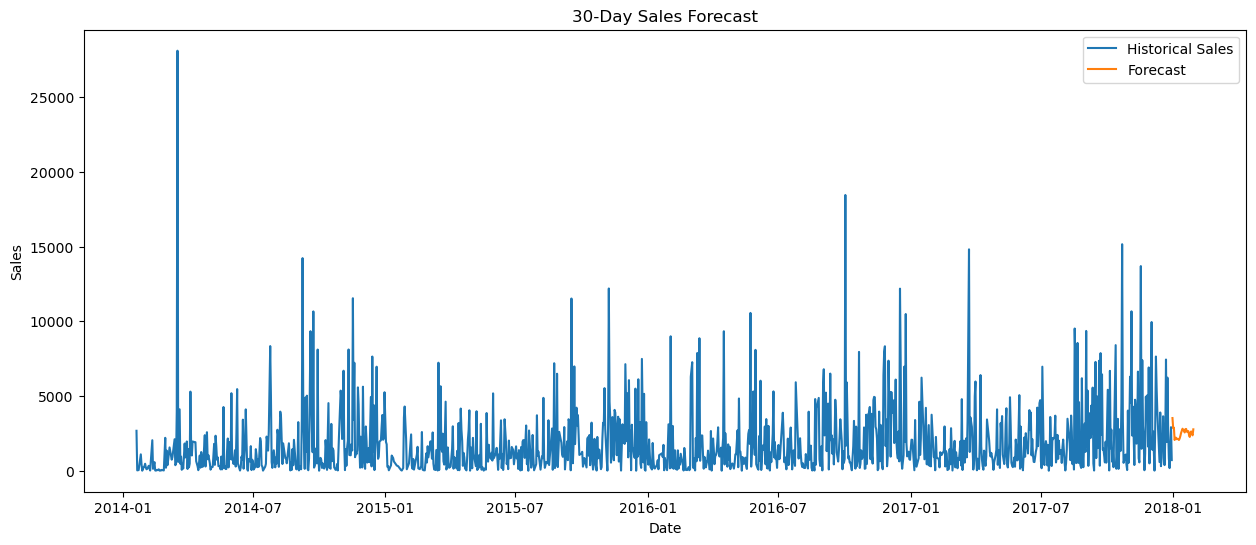

In [38]:
plt.figure(figsize=(15,6))

plt.plot(daily_sales['Order Date'], daily_sales['Sales'], label='Historical Sales')
plt.plot(future_df['Order Date'], future_df['Forecasted_Sales'], label='Forecast')

plt.title('30-Day Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()

plt.savefig('../outputs/future_forecast.png')
plt.show()